The purpose of this notebook is primarily to explore how AR(1) fitting works and how sensitive it is to sample length. In particular, I want to see how well AR(1) fitting works on the OH series and the output of the methane box model forced with OH.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from methane_noise_forcing.noise import (
    simulate_white_noise_ar1,
    calculate_white_noise_ar1_params,
)
from methane_noise_forcing.stats.fit import (
    fit_ar1_conditional_ols,
    fit_ar1_exact_mle,
    tau_from_phi,
    bootstrap_tau_parametric,
)
from methane_noise_forcing.stats.validation import acf, ljung_box, durbin_watson
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
    large_font,
)

plt.rcParams.update(matplotlib_rcparams)
plt.rcParams["figure.dpi"] = 200

# simulate AR(1) and validate fitting procedure

In [2]:
def simulate_ar1(
    timescale,
    dt,
    n_years,
    n_ens=1,
    variance=100,
):
    ar1_params = calculate_white_noise_ar1_params(
        tau_years=timescale,
        dt_years=dt,
        variance=variance,
    )
    red_noise, white_noise = simulate_white_noise_ar1(
        phi=ar1_params.phi,
        sigma_eps=ar1_params.sigma_eps,
        n_steps=int(n_years / dt),
        n_ens=n_ens,
    )
    noise = xr.Dataset(
        {
            "red_noise": (("time"), red_noise[0, :]),
            "white_noise": (("time"), white_noise[0, :]),
        },
        coords={
            "time": np.arange(0, n_years, dt),
        },
    )
    return noise

In [ ]:
## simulate noise, sweeping over timescales and dt
timescales = [0.1, 1, 10, 100, 1000]
dts = [0.1, 1]
n_years = 1000
simulated_noises = {}
for dt in dts:
    simulated_noises_dt = []
    for timescale in timescales:
        key = f"tau_{timescale}_dt_{dt}"
        simulated_noises_dt.append(simulate_ar1(
            timescale=timescale,
            dt=dt,
            n_years=n_years,
            n_ens=1,
            variance=100,
        ).expand_dims(["timescale"]).assign_coords(
            timescale=[timescale],
        ))
    simulated_noises[dt] = xr.concat(simulated_noises_dt, dim="timescale")

In [16]:
## for each simulation, fit timescale and compute bootstrap CIs for each method
fit_methods = {
    "conditional_ols": fit_ar1_conditional_ols,
    "exact_mle": fit_ar1_exact_mle,
}
n_bootstrap=100
fit_results = {}
for dt in dts:
    fit_results_dt = []
    for timescale in timescales:
        sim_data = simulated_noises[dt].sel(timescale=timescale)["red_noise"].values
        fit_results_methods = {}
        for method_name, fit_method in fit_methods.items():
            phi_hat, sigma2_hat = fit_method(sim_data, dt)
            tau_hat = tau_from_phi(phi_hat, dt=dt)
            _, (ci_lower, ci_upper) = bootstrap_tau_parametric(
                phi_hat=phi_hat,
                sigma2_hat=sigma2_hat,
                dt=dt,
                n_series=len(sim_data),
                n_bootstrap=n_bootstrap,
                fit_method=method_name,
            )
            fit_results_methods[method_name] = {
                "phi_hat": phi_hat,
                "tau_hat": tau_hat,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper,
            }
        fit_results_dt.append(xr.Dataset(
            {
                method_name: (("statistic"), [
                    fit_results_methods[method_name]["phi_hat"],
                    fit_results_methods[method_name]["tau_hat"],
                    fit_results_methods[method_name]["ci_lower"],
                    fit_results_methods[method_name]["ci_upper"],
                ]) for method_name in fit_methods.keys()
            },
            coords={
                "statistic": ["phi_hat", "tau_hat", "ci_lower", "ci_upper"],
            },
        ).expand_dims(["timescale"]).assign_coords(
            timescale=[timescale],
        ))
    fit_results[dt] = xr.concat(fit_results_dt, dim="timescale")

/home/disk/p/emei/repos/methane_noise_forcing/src/methane_noise_forcing/stats/fit.py:21: UserWarning: Fitted AR(1) coefficient phi=0.9989 is very close to unit root; estimates may be unreliable.
  warnings.warn(
/home/disk/p/emei/repos/methane_noise_forcing/src/methane_noise_forcing/stats/fit.py:21: UserWarning: Fitted AR(1) coefficient phi=0.9993 is very close to unit root; estimates may be unreliable.
  warnings.warn(
/home/disk/p/emei/repos/methane_noise_forcing/src/methane_noise_forcing/stats/fit.py:21: UserWarning: Fitted AR(1) coefficient phi=0.9988 is very close to unit root; estimates may be unreliable.
  warnings.warn(
/home/disk/p/emei/repos/methane_noise_forcing/src/methane_noise_forcing/stats/fit.py:21: UserWarning: Fitted AR(1) coefficient phi=0.9982 is very close to unit root; estimates may be unreliable.
  warnings.warn(
/home/disk/p/emei/repos/methane_noise_forcing/src/methane_noise_forcing/stats/fit.py:21: UserWarning: Fitted AR(1) coefficient phi=0.9986 is very close 

Text(0.05, 0.5, 'Fitted Timescale (years)')

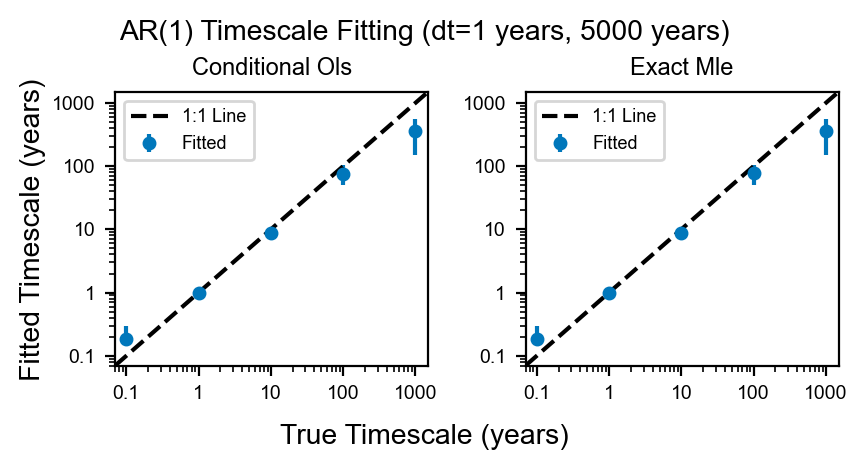

In [18]:
## plot fitted timescale vs. true timescale with CIs
dt_plot = 1
timescales_lim = [0.07, 1500]
timescale_ticks = [0.1, 1, 10, 100, 1000]
fig, axs = plt.subplots(1, 2, figsize=(fig_width_options["two_column_small"], 2.5), tight_layout=True)
axs = axs.flatten()
for i, method_name in enumerate(fit_methods.keys()):
    ax = axs[i]
    fit_result = fit_results[dt_plot]
    ax.errorbar(
        fit_result["timescale"],
        fit_result[method_name].sel(statistic="tau_hat"),
        yerr=[
            fit_result[method_name].sel(statistic="tau_hat") - fit_result[method_name].sel(statistic="ci_lower"),
            fit_result[method_name].sel(statistic="ci_upper") - fit_result[method_name].sel(statistic="tau_hat"),
        ],
        fmt="o",
        markersize=4,
        color=colors_vibrant["blue"],
        label="Fitted",
    )
    ax.plot(
        timescales_lim,
        timescales_lim,
        "k--",
        label="1:1 Line",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(timescales_lim)
    ax.set_ylim(timescales_lim)
    ax.set_title(method_name.replace("_", " ").title())
    ax.set_xticks(timescale_ticks)
    ax.set_yticks(timescale_ticks)
    ax.set_xticklabels([str(tick) for tick in timescale_ticks])
    ax.set_yticklabels([str(tick) for tick in timescale_ticks])
    ax.legend(fontsize=large_font - 2)

# labels
fig.suptitle(f"AR(1) Timescale Fitting (dt={dt_plot} years, {n_years} years)", y=0.92)
fig.supxlabel("True Timescale (years)", y=0.06)
fig.supylabel("Fitted Timescale (years)", x=0.05)

## validation metrics (acf, durbin-watson, ljung-box Q-statistic)

In [ ]:
dt_calc = 0.1
timescale = 1000
method_name = "exact_mle"
series = simulated_noises[dt_calc].sel(timescale=timescale)["red_noise"].values
residuals = series - np.mean(series)
phi_hat = fit_results[dt_calc].sel(timescale=timescale, statistic="phi_hat")[method_name].values.item()
# phi_hat = np.exp(-dt_calc / fit_results[dt_calc].sel(timescale=timescale, statistic="tau_hat")[method_name].values.item())
residuals = series[1:] - phi_hat * series[:-1]
acf_residuals = acf(residuals, nlags=20)
acf_residuals

array([ 1.00000000e+00,  1.22492885e-02,  8.68569556e-03, -1.56214026e-02,
        5.54397042e-04, -1.00180519e-02, -2.46804249e-02,  7.37928395e-03,
        1.28798997e-02, -1.56296804e-02,  2.59476322e-03, -1.30347928e-02,
        2.92720086e-02, -3.06130418e-02,  2.08028366e-02, -1.17703511e-02,
        3.24980312e-02,  2.31655529e-02, -1.24028297e-02,  5.67523596e-03,
       -1.60865350e-02])

In [23]:
lb = ljung_box(residuals, lags=10)
lb

{'Q': 8.264191753657611, 'df': 10, 'pvalue': 0.6030482320467969}

In [24]:
dw = durbin_watson(residuals)
dw

1.9750457187789743

These tests can tell when the fit is obviously bad, but care needs to be taken when the autocorrelation fit is near 1 - an obvious case is when the dt_calc is 0.1 and timescale is around 1000 years. Even when the length of the sample is increased, both methods (OLS and exact MLE) have trouble fitting the timescale correctly.

## compare AR(1) spectrum to fitted spectrum
Use fitted timescales to get theoretical AR(1) spectra

# compare OH variability to AR(1) fits

## simulate methane variability and compare to expected spectrum